# Supplementary robustness and subclass figures

This notebook regenerates three missing supplementary figures for the thesis:

1. CDS-removal robustness for per-gene $V_G$
2. Biophysical decomposition of promoter-core constraint
3. Distal- vs proximal-biased ClinGen HI subclasses

All figures are exported directly into the thesis supplementary figure directory.


In [7]:
from pathlib import Path
from collections import defaultdict
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy import stats

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
MASTER_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOK_DIR))

from config import GENE_PATHS, VARIANT_PATHS, SOURCE_PALETTE
from thesis_style import apply_thesis_style, add_panel_letters, save_figure

apply_thesis_style()

THESIS_SUPP_FIG_DIR = MASTER_ROOT / '2026SS-thesis-medical-engineering-msc' / 'Figures' / 'Supplementary'
THESIS_SUPP_FIG_DIR.mkdir(parents=True, exist_ok=True)

GTF_PATH = MASTER_ROOT / 'seq2expr-variance' / 'data' / 'initial' / 'gencode.v48.annotation.gtf'

HI_COLOR = SOURCE_PALETTE['clingen']
BG_COLOR = SOURCE_PALETTE['background']
DISTAL_COLOR = HI_COLOR
PROXIMAL_COLOR = '#f28e2b'

DATASET_SPECS = {
    'background': {
        'label': 'Background observed',
        'short_label': 'Background',
        'af_col': 'AF',
        'gene_vg_col': 'vg_predicted',
        'color': BG_COLOR,
    },
    'clingen': {
        'label': 'ClinGen HI observed',
        'short_label': 'ClinGen HI',
        'af_col': 'AF',
        'gene_vg_col': 'vg_predicted',
        'color': HI_COLOR,
    },
    'background_null': {
        'label': 'Background synthetic',
        'short_label': 'Background synthetic',
        'af_col': 'perm_AF',
        'gene_vg_col': 'vg_predicted_perm',
        'color': '#8c87f5',
    },
    'clingen_null': {
        'label': 'ClinGen HI synthetic',
        'short_label': 'ClinGen HI synthetic',
        'af_col': 'perm_AF',
        'gene_vg_col': 'vg_predicted_perm',
        'color': '#5fbf8f',
    },
}

GENE_FRAMES = {key: pl.read_parquet(GENE_PATHS[key]) for key in DATASET_SPECS}
TARGET_GENE_IDS = {
    gene_id.split('.')[0]
    for frame in GENE_FRAMES.values()
    for gene_id in frame['gene_id'].to_list()
    if isinstance(gene_id, str)
}

print(f'Loaded {sum(frame.height for frame in GENE_FRAMES.values())} total gene rows across {len(GENE_FRAMES)} datasets.')
print(f'Target genes for CDS-overlap parsing: {len(TARGET_GENE_IDS)}')
print(f'Figures will be written to: {THESIS_SUPP_FIG_DIR}')


Loaded 1330 total gene rows across 4 datasets.
Target genes for CDS-overlap parsing: 661
Figures will be written to: /Users/markus/master-thesis-lappalainen/2026SS-thesis-medical-engineering-msc/Figures/Supplementary


In [8]:
def load_gene_cds_intervals(gtf_path: Path, target_gene_ids: set[str]):
    attr_gene_id = re.compile(r'gene_id "([^"]+)"')
    intervals: dict[tuple[str, str], list[tuple[int, int]]] = {}

    with gtf_path.open() as handle:
        for line in handle:
            if not line or line.startswith('#'):
                continue
            chrom, _, feature, start, end, _, _, _, attrs = line.strip().split('	')
            if feature != 'CDS':
                continue
            match = attr_gene_id.search(attrs)
            if not match:
                continue
            gene_id = match.group(1).split('.')[0]
            if gene_id not in target_gene_ids:
                continue
            intervals.setdefault((gene_id, chrom.replace('chr', '')), []).append((int(start), int(end)))

    merged: dict[tuple[str, str], tuple[np.ndarray, np.ndarray]] = {}
    for key, raw_intervals in intervals.items():
        merged_intervals: list[list[int]] = []
        for start, end in sorted(raw_intervals):
            if not merged_intervals or start > merged_intervals[-1][1] + 1:
                merged_intervals.append([start, end])
            else:
                merged_intervals[-1][1] = max(merged_intervals[-1][1], end)
        merged[key] = (
            np.array([item[0] for item in merged_intervals], dtype=np.int64),
            np.array([item[1] for item in merged_intervals], dtype=np.int64),
        )
    return merged


CDS_INTERVALS = load_gene_cds_intervals(GTF_PATH, TARGET_GENE_IDS)
print(f'Parsed merged CDS intervals for {len(CDS_INTERVALS)} gene/chromosome combinations.')


def compute_cds_overlap_mask(gene_ids: np.ndarray, chroms: np.ndarray, positions: np.ndarray, cds_intervals):
    mask = np.zeros(len(positions), dtype=bool)
    grouped_indices: defaultdict[tuple[str, str], list[int]] = defaultdict(list)

    for idx, (gene_id, chrom) in enumerate(zip(gene_ids, chroms)):
        grouped_indices[(gene_id, chrom)].append(idx)

    for key, indices in grouped_indices.items():
        interval_arrays = cds_intervals.get(key)
        if interval_arrays is None:
            continue
        starts, ends = interval_arrays
        indices = np.array(indices, dtype=np.int64)
        pos_subset = positions[indices]
        insertion = np.searchsorted(starts, pos_subset, side='right') - 1
        valid = insertion >= 0
        hit = np.zeros(len(indices), dtype=bool)
        hit[valid] = pos_subset[valid] <= ends[insertion[valid]]
        mask[indices] = hit

    return mask


def compute_cds_removed_summary(dataset_key: str):
    spec = DATASET_SPECS[dataset_key]
    variant_df = pl.read_parquet(
        VARIANT_PATHS[dataset_key],
        columns=['gene_id', 'CHROM', 'POS', 'raw_score', spec['af_col']],
    )

    gene_ids = np.array([
        value.split('.')[0] if isinstance(value, str) else value
        for value in variant_df['gene_id'].to_list()
    ], dtype=object)
    chroms = np.array([
        str(value).replace('chr', '')
        for value in variant_df['CHROM'].to_list()
    ], dtype=object)
    positions = variant_df['POS'].to_numpy()
    allele_frequency = variant_df[spec['af_col']].to_numpy()
    raw_score = variant_df['raw_score'].to_numpy()

    cds_mask = compute_cds_overlap_mask(gene_ids, chroms, positions, CDS_INTERVALS)
    vg = 2 * allele_frequency * (1 - allele_frequency) * raw_score * raw_score

    variant_pdf = pd.DataFrame({'gene_id': gene_ids, 'vg': vg, 'is_cds': cds_mask})
    vg_all = variant_pdf.groupby('gene_id', sort=False)['vg'].sum()
    vg_no_cds = variant_pdf.loc[~variant_pdf['is_cds']].groupby('gene_id', sort=False)['vg'].sum()

    gene_frame = GENE_FRAMES[dataset_key].select(['gene_id', spec['gene_vg_col']])
    summary = pd.DataFrame({
        'gene_id': [
            value.split('.')[0] if isinstance(value, str) else value
            for value in gene_frame['gene_id'].to_list()
        ],
        'vg_reference': gene_frame[spec['gene_vg_col']].to_list(),
    }).set_index('gene_id')

    summary['vg_all'] = vg_all
    summary['vg_no_cds'] = vg_no_cds
    summary['vg_no_cds'] = summary['vg_no_cds'].fillna(0.0)
    summary['pct_change'] = np.where(
        summary['vg_all'] > 0,
        (summary['vg_all'] - summary['vg_no_cds']) / summary['vg_all'] * 100,
        0.0,
    )
    summary = summary.fillna(0.0)

    corr = float(np.corrcoef(summary['vg_reference'], summary['vg_no_cds'])[0, 1])
    median_pct_change = float(np.median(summary['pct_change']))
    return {
        'summary': summary,
        'corr': corr,
        'median_pct_change': median_pct_change,
        'n_genes_with_cds_overlap': int((summary['vg_all'] > summary['vg_no_cds']).sum()),
    }


cds_results = {key: compute_cds_removed_summary(key) for key in DATASET_SPECS}
for key, result in cds_results.items():
    print(
        key,
        f"r={result['corr']:.3f}",
        f"median delta={result['median_pct_change']:.2f}%",
        f"genes with CDS-overlap loss={result['n_genes_with_cds_overlap']}",
    )


Parsed merged CDS intervals for 644 gene/chromosome combinations.
background r=0.992 median delta=0.25% genes with CDS-overlap loss=297
clingen r=0.999 median delta=0.06% genes with CDS-overlap loss=246
background_null r=0.999 median delta=1.20% genes with CDS-overlap loss=296
clingen_null r=0.999 median delta=0.45% genes with CDS-overlap loss=248


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/1621598614.py:41: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


[thesis_style] saved supplementary_CDS_removal_correlation.pdf


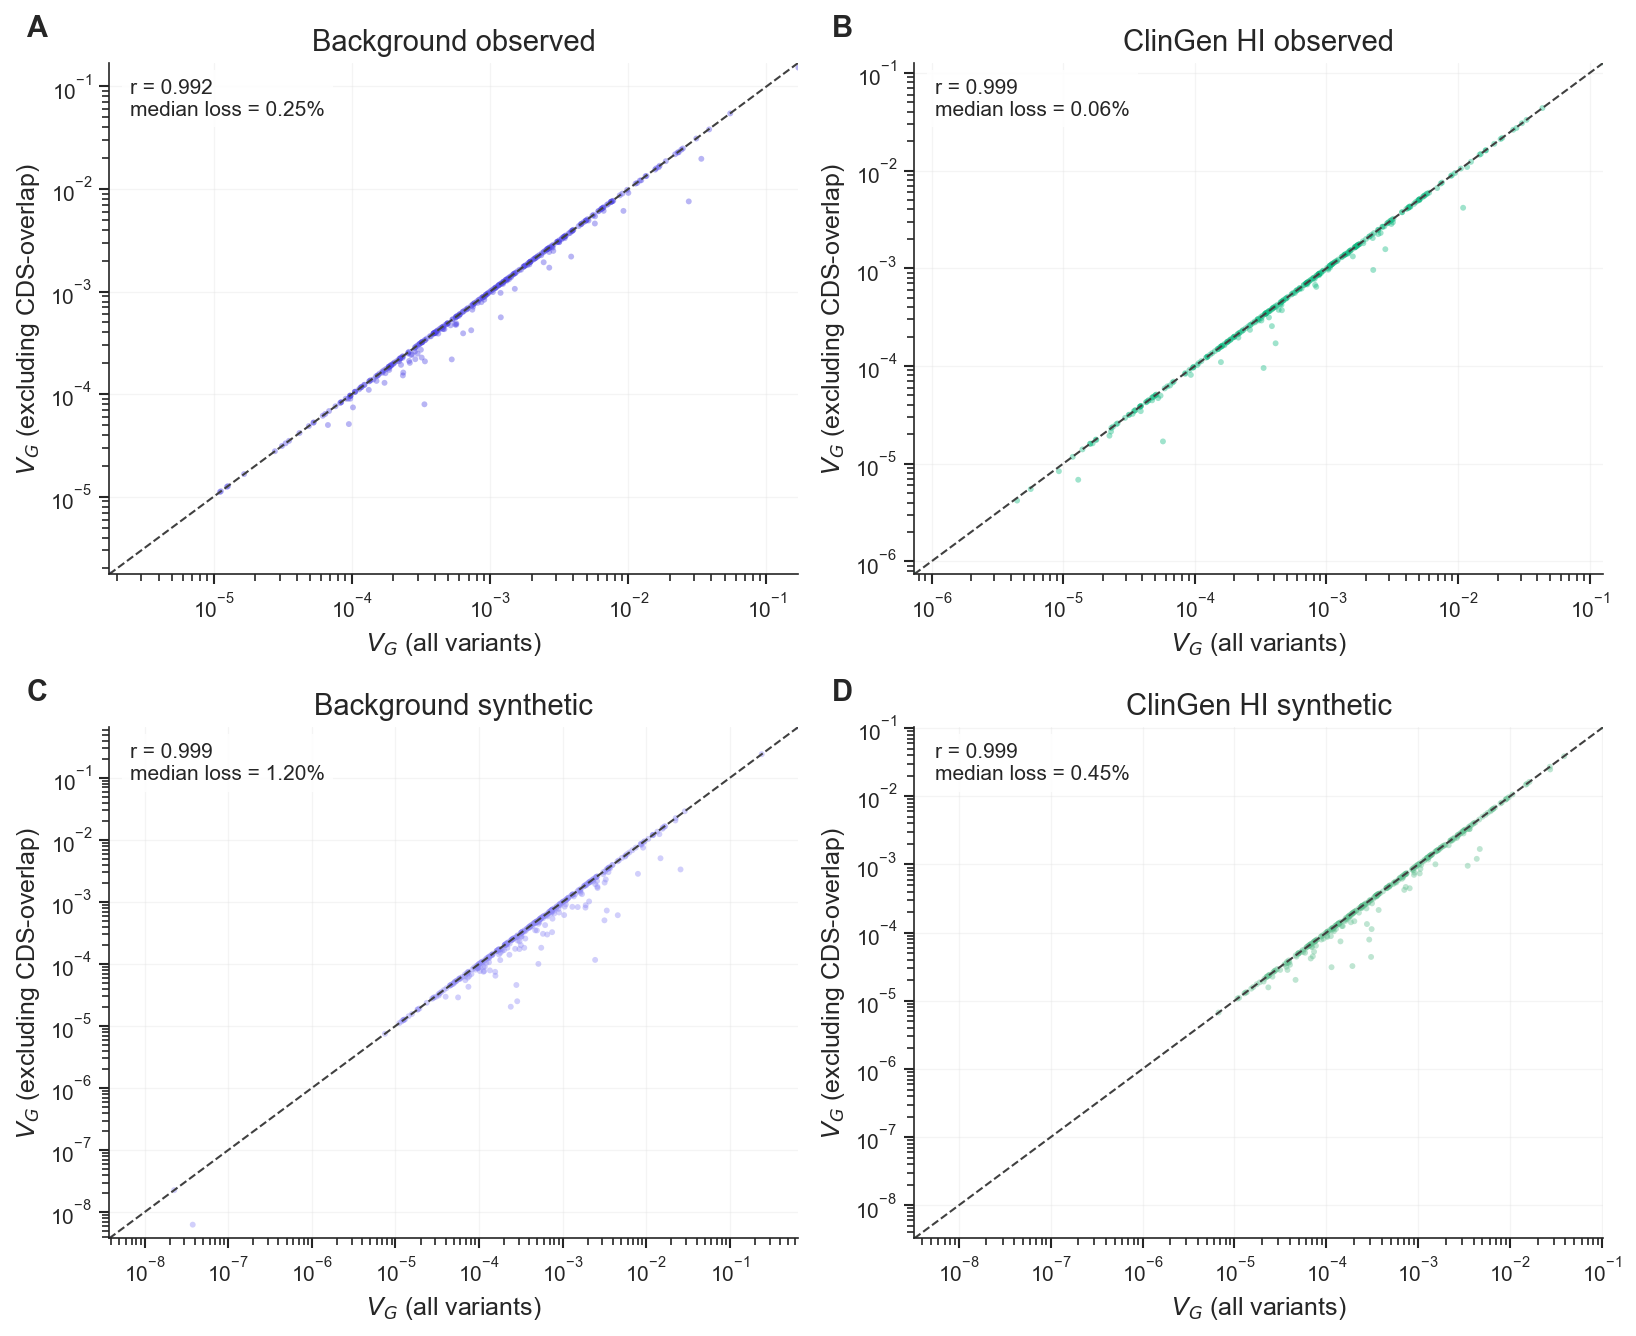

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
order = ['background', 'clingen', 'background_null', 'clingen_null']

for ax, key in zip(axes, order):
    spec = DATASET_SPECS[key]
    result = cds_results[key]
    summary = result['summary']

    x = np.maximum(summary['vg_reference'].to_numpy(dtype=float), 1e-12)
    y = np.maximum(summary['vg_no_cds'].to_numpy(dtype=float), 1e-12)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())

    ax.set_axisbelow(True)
    ax.scatter(x, y, s=8, alpha=0.4, color=spec['color'], edgecolor='none')
    ax.plot([lo, hi], [lo, hi], linestyle='--', color='0.25', linewidth=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(spec['label'])
    ax.set_xlabel(r'$V_G$ (all variants)')
    ax.set_ylabel(r'$V_G$ (excluding CDS-overlap)')
    ax.text(
        0.03,
        0.97,
        f"r = {result['corr']:.3f}\nmedian loss = {result['median_pct_change']:.2f}%",
        transform=ax.transAxes,
        ha='left',
        va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'),
        fontsize=10,
    )
    ax.grid(True, which='major', color='0.88', linestyle='-', linewidth=0.6)
    ax.grid(False, which='minor')

sns.despine(fig=fig)

add_panel_letters(axes)
fig.tight_layout()
save_figure(fig, 'supplementary_CDS_removal_correlation', outdir=THESIS_SUPP_FIG_DIR, formats=('pdf',))
plt.show()

## Promoter-core biophysical decomposition

This figure separates promoter-core depletion into variant count, mean effect size, and total promoter-core $V_G$.


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/1320134260.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/1320134260.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/1320134260.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/1320134260.py:73: UserWarning: The figure layout has changed to tight
  fig.tight_l

[thesis_style] saved supplementary_biophysical_promoter_decomposition.pdf


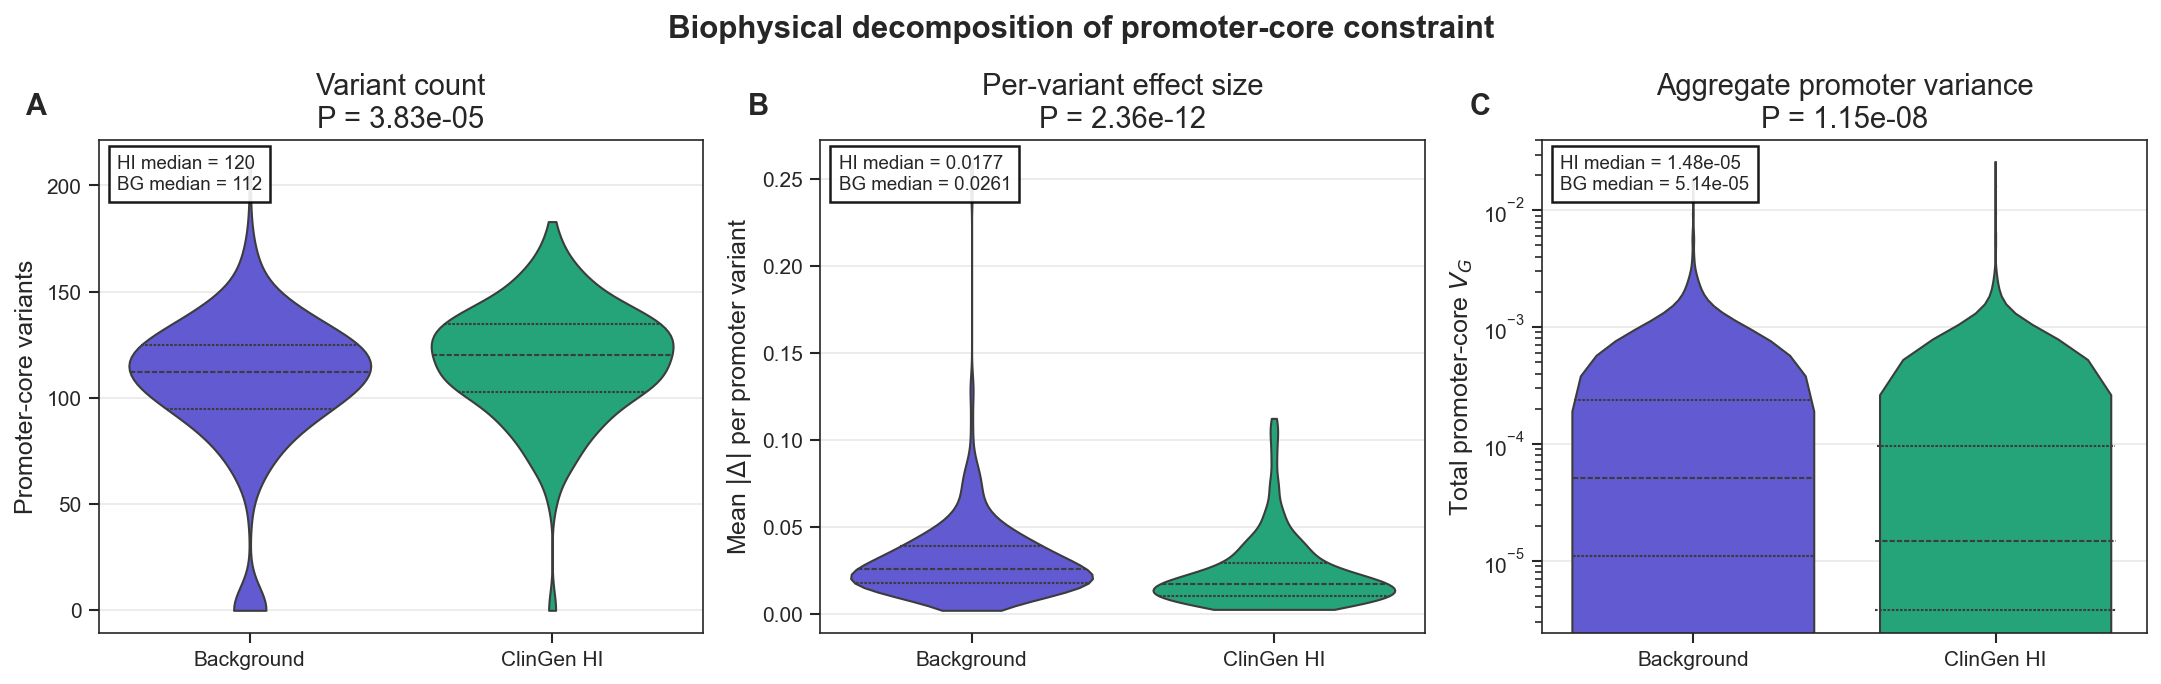

{'n_variants_promoter_core': {'hi_median': 120.0,
  'bg_median': 112.0,
  'p': 3.8268513369304024e-05},
 'mean_abs_promoter_core': {'hi_median': 0.017662605850553032,
  'bg_median': 0.02611914293641964,
  'p': 2.359064115611178e-12},
 'vg_promoter_core': {'hi_median': 1.481963287315557e-05,
  'bg_median': 5.137410779569608e-05,
  'p': 1.1474857137666838e-08}}

In [10]:
promoter_specs = [
    {
        'column': 'n_variants_promoter_core',
        'ylabel': 'Promoter-core variants',
        'title': 'Variant count',
        'log_scale': False,
        'alternative': 'two-sided',
    },
    {
        'column': 'mean_abs_promoter_core',
        'ylabel': r'Mean $|\Delta|$ per promoter variant',
        'title': 'Per-variant effect size',
        'log_scale': False,
        'alternative': 'less',
    },
    {
        'column': 'vg_promoter_core',
        'ylabel': r'Total promoter-core $V_G$',
        'title': 'Aggregate promoter variance',
        'log_scale': True,
        'alternative': 'less',
    },
]

promoter_stats = {}
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6))

for ax, spec in zip(axes, promoter_specs):
    hi_vals = pd.Series(GENE_FRAMES['clingen'][spec['column']].to_list(), dtype='float64').dropna().to_numpy()
    bg_vals = pd.Series(GENE_FRAMES['background'][spec['column']].to_list(), dtype='float64').dropna().to_numpy()
    stat, p_value = stats.mannwhitneyu(hi_vals, bg_vals, alternative=spec['alternative'])
    promoter_stats[spec['column']] = {
        'hi_median': float(np.median(hi_vals)),
        'bg_median': float(np.median(bg_vals)),
        'p': float(p_value),
    }

    plot_df = pd.DataFrame({
        'value': np.concatenate([bg_vals, hi_vals]),
        'group': ['Background'] * len(bg_vals) + ['ClinGen HI'] * len(hi_vals),
    })

    sns.violinplot(
        data=plot_df,
        x='group',
        y='value',
        order=['Background', 'ClinGen HI'],
        palette={'Background': BG_COLOR, 'ClinGen HI': HI_COLOR},
        cut=0,
        inner='quartile',
        linewidth=1,
        ax=ax,
    )

    ax.set_xlabel('')
    ax.set_ylabel(spec['ylabel'])
    ax.set_title(f"{spec['title']}\nP = {p_value:.2e}")
    if spec['log_scale']:
        ax.set_yscale('log')
    ax.text(
        0.03,
        0.97,
        f"HI median = {np.median(hi_vals):.3g}\nBG median = {np.median(bg_vals):.3g}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
        fontsize=9,
    )

add_panel_letters(axes)
fig.suptitle('Biophysical decomposition of promoter-core constraint', fontsize=15, fontweight='bold')
fig.tight_layout()
save_figure(fig, 'supplementary_biophysical_promoter_decomposition', outdir=THESIS_SUPP_FIG_DIR, formats=('pdf',))
plt.show()

promoter_stats


## Distal- vs proximal-biased ClinGen HI subclasses

ClinGen HI genes are split by distal-upstream to promoter-core $V_G$ ratio greater than 1.


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/344973130.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/344973130.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/344973130.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_85760/344973130.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

[thesis_style] saved supplementary_distal_vs_proximal_characteristics.pdf


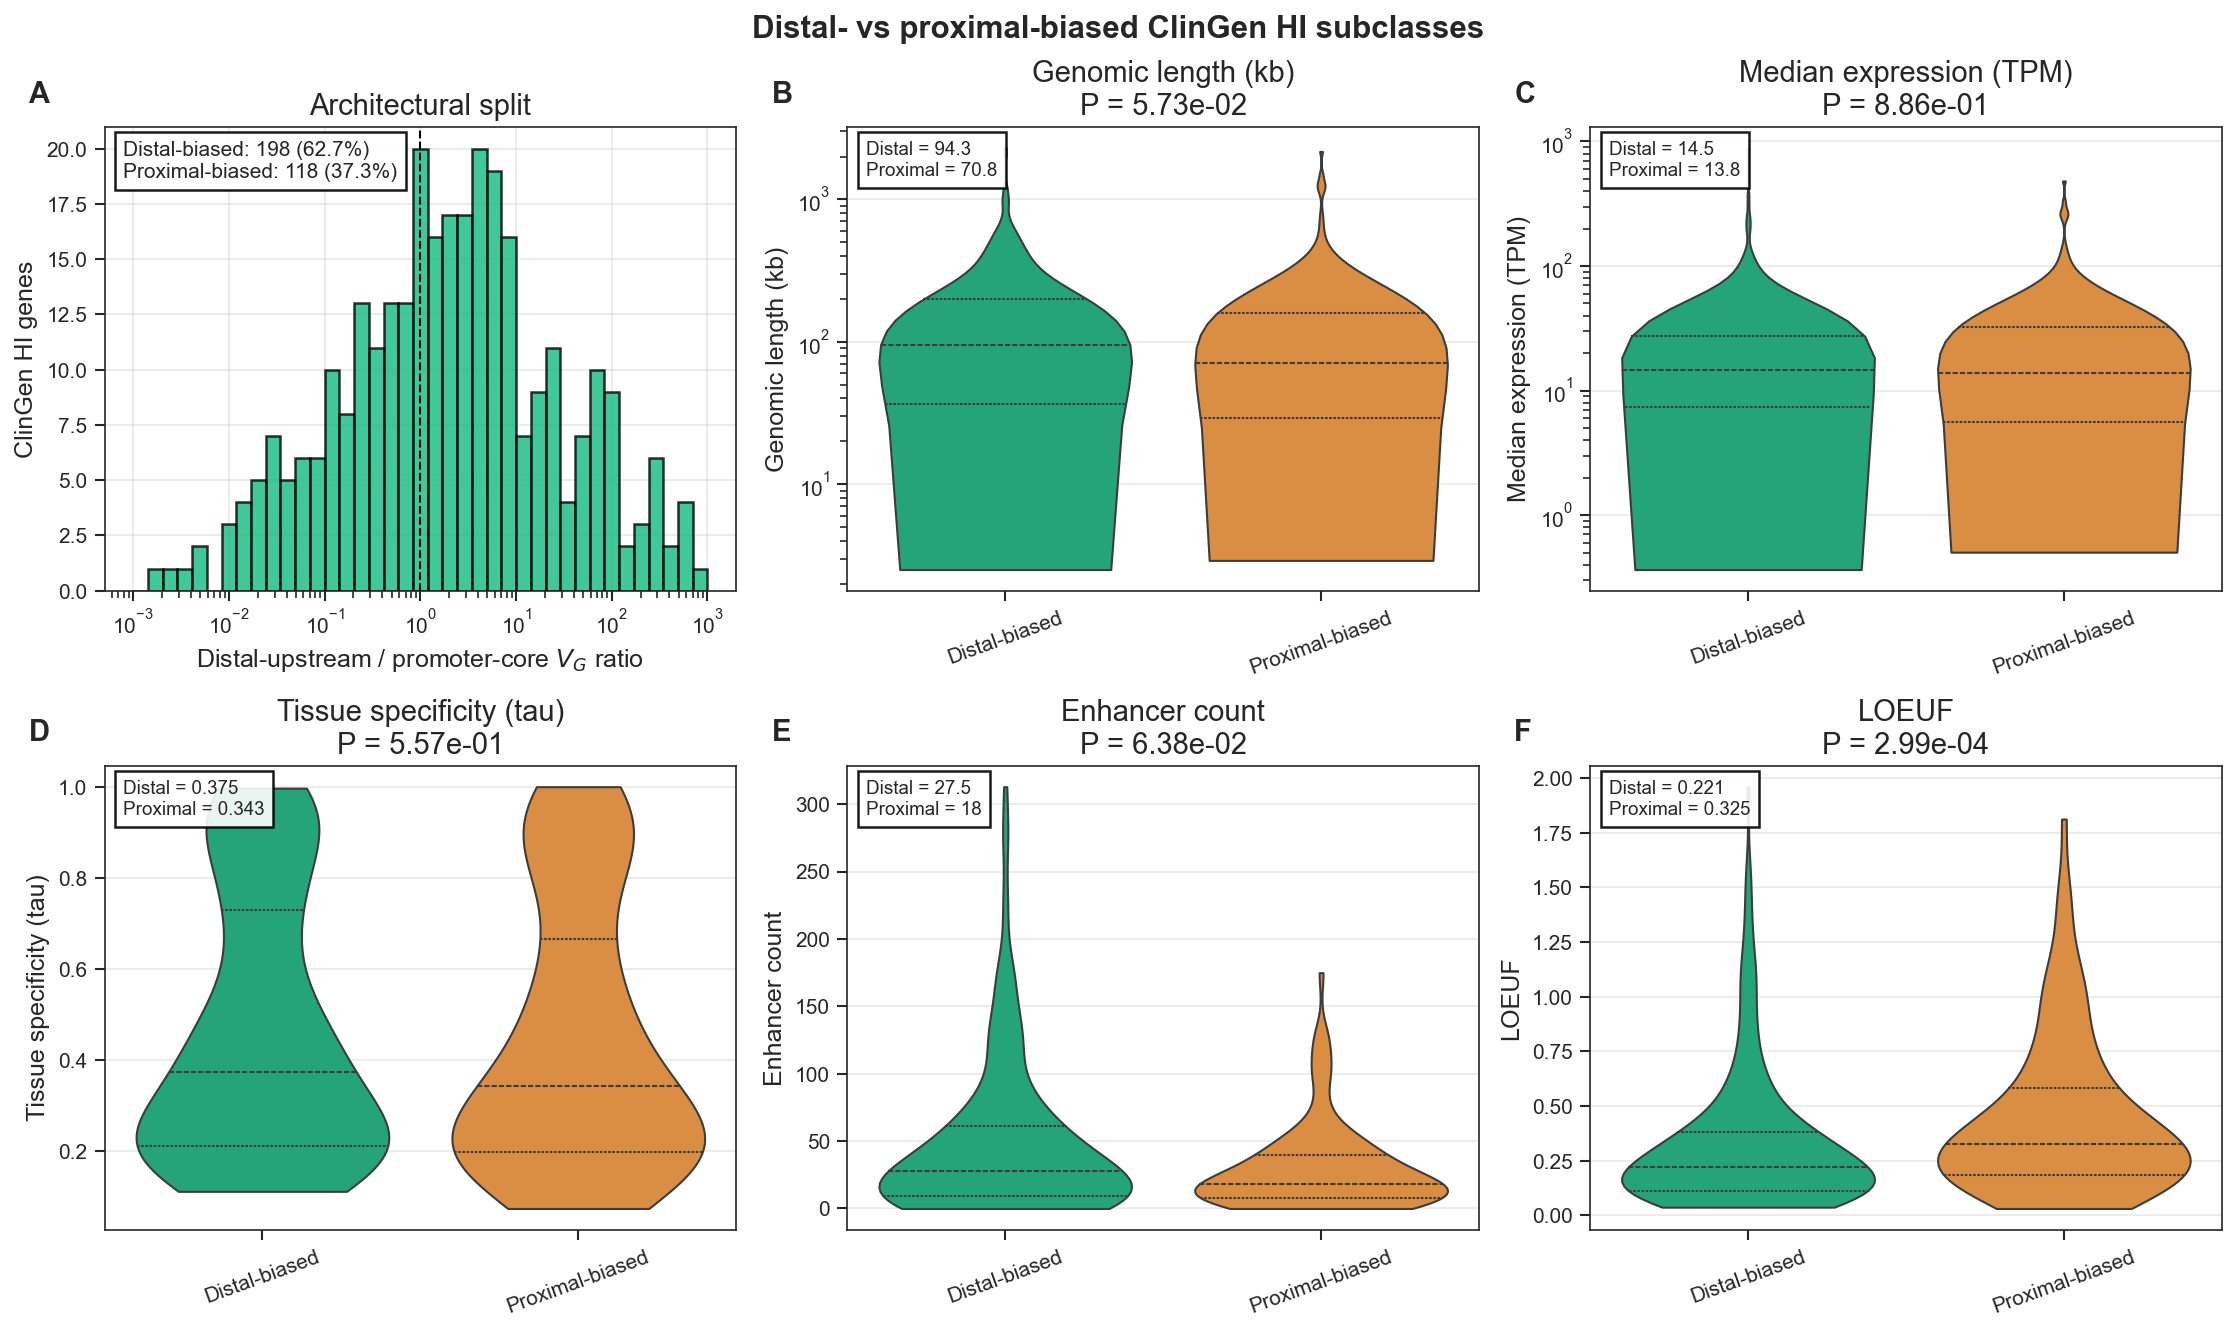

{'genomic_length': {'distal_median': 94.3285,
  'proximal_median': 70.812,
  'p': 0.05729596724379629},
 'median_tpm': {'distal_median': 14.5471357037037,
  'proximal_median': 13.8259988888889,
  'p': 0.8864823551272016},
 'tau': {'distal_median': 0.3745953275,
  'proximal_median': 0.342684884,
  'p': 0.557183014423734},
 'num_enh': {'distal_median': 27.5,
  'proximal_median': 18.0,
  'p': 0.06382484534330737},
 'loeuf_score': {'distal_median': 0.221,
  'proximal_median': 0.325,
  'p': 0.00029940717413425944}}

In [11]:
hi_df = GENE_FRAMES['clingen'].with_columns(
    (pl.col('vg_distal_upstream') / (pl.col('vg_promoter_core') + 1e-10)).alias('distal_to_core_ratio')
)
hi_pdf = hi_df.to_pandas()
hi_pdf['architectural_class'] = np.where(
    hi_pdf['distal_to_core_ratio'] > 1.0,
    'Distal-biased',
    'Proximal-biased',
)

class_counts = hi_pdf['architectural_class'].value_counts()
n_distal = int(class_counts['Distal-biased'])
n_proximal = int(class_counts['Proximal-biased'])
pct_distal = 100 * n_distal / len(hi_pdf)
pct_proximal = 100 * n_proximal / len(hi_pdf)

feature_specs = [
    ('genomic_length', 'Genomic length (kb)', True, lambda s: s / 1000.0),
    ('median_tpm', 'Median expression (TPM)', True, lambda s: s),
    ('tau', 'Tissue specificity (tau)', False, lambda s: s),
    ('num_enh', 'Enhancer count', False, lambda s: s),
    ('loeuf_score', 'LOEUF', False, lambda s: s),
]

subclass_stats = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

ratio_ax = axes[0]
ratio_vals = np.clip(hi_pdf['distal_to_core_ratio'].to_numpy(dtype=float), 1e-4, None)
ratio_bins = np.logspace(-3, 3, 40)
ratio_ax.hist(ratio_vals, bins=ratio_bins, color=HI_COLOR, alpha=0.8, edgecolor='black')
ratio_ax.axvline(1.0, linestyle='--', color='black', linewidth=1)
ratio_ax.set_xscale('log')
ratio_ax.set_xlabel(r'Distal-upstream / promoter-core $V_G$ ratio')
ratio_ax.set_ylabel('ClinGen HI genes')
ratio_ax.set_title('Architectural split')
ratio_ax.text(
    0.03,
    0.97,
    f"Distal-biased: {n_distal} ({pct_distal:.1f}%)\nProximal-biased: {n_proximal} ({pct_proximal:.1f}%)",
    transform=ratio_ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
    fontsize=10,
)

for ax, (column, ylabel, log_scale, transform) in zip(axes[1:], feature_specs):
    subset = hi_pdf[[column, 'architectural_class']].dropna().copy()
    subset[column] = transform(subset[column])
    distal = subset.loc[subset['architectural_class'] == 'Distal-biased', column].to_numpy(dtype=float)
    proximal = subset.loc[subset['architectural_class'] == 'Proximal-biased', column].to_numpy(dtype=float)
    stat, p_value = stats.mannwhitneyu(distal, proximal, alternative='two-sided')
    subclass_stats[column] = {
        'distal_median': float(np.median(distal)),
        'proximal_median': float(np.median(proximal)),
        'p': float(p_value),
    }

    sns.violinplot(
        data=subset,
        x='architectural_class',
        y=column,
        order=['Distal-biased', 'Proximal-biased'],
        palette={'Distal-biased': DISTAL_COLOR, 'Proximal-biased': PROXIMAL_COLOR},
        cut=0,
        inner='quartile',
        linewidth=1,
        ax=ax,
    )

    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\nP = {p_value:.2e}")
    ax.tick_params(axis='x', rotation=20)
    if log_scale:
        ax.set_yscale('log')
    ax.text(
        0.03,
        0.97,
        f"Distal = {np.median(distal):.3g}\nProximal = {np.median(proximal):.3g}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
        fontsize=9,
    )

add_panel_letters(axes)
fig.suptitle('Distal- vs proximal-biased ClinGen HI subclasses', fontsize=15, fontweight='bold')
fig.tight_layout()
save_figure(fig, 'supplementary_distal_vs_proximal_characteristics', outdir=THESIS_SUPP_FIG_DIR, formats=('pdf',))
plt.show()

subclass_stats


In [12]:
print('CDS-removal summary:')
for key in ['background', 'clingen', 'background_null', 'clingen_null']:
    result = cds_results[key]
    print(f"  {DATASET_SPECS[key]['label']}: r={result['corr']:.3f}, median V_G loss={result['median_pct_change']:.2f}%")

print()
print('Promoter decomposition summary:')
for column, stats_dict in promoter_stats.items():
    print(f"  {column}: HI median={stats_dict['hi_median']:.4g}, BG median={stats_dict['bg_median']:.4g}, p={stats_dict['p']:.2e}")

print()
print('Subclass summary:')
print(f"  Distal-biased={n_distal} ({pct_distal:.1f}%), proximal-biased={n_proximal} ({pct_proximal:.1f}%)")
for column, stats_dict in subclass_stats.items():
    print(f"  {column}: distal={stats_dict['distal_median']:.4g}, proximal={stats_dict['proximal_median']:.4g}, p={stats_dict['p']:.2e}")


CDS-removal summary:
  Background observed: r=0.992, median V_G loss=0.25%
  ClinGen HI observed: r=0.999, median V_G loss=0.06%
  Background synthetic: r=0.999, median V_G loss=1.20%
  ClinGen HI synthetic: r=0.999, median V_G loss=0.45%

Promoter decomposition summary:
  n_variants_promoter_core: HI median=120, BG median=112, p=3.83e-05
  mean_abs_promoter_core: HI median=0.01766, BG median=0.02612, p=2.36e-12
  vg_promoter_core: HI median=1.482e-05, BG median=5.137e-05, p=1.15e-08

Subclass summary:
  Distal-biased=198 (62.7%), proximal-biased=118 (37.3%)
  genomic_length: distal=94.33, proximal=70.81, p=5.73e-02
  median_tpm: distal=14.55, proximal=13.83, p=8.86e-01
  tau: distal=0.3746, proximal=0.3427, p=5.57e-01
  num_enh: distal=27.5, proximal=18, p=6.38e-02
  loeuf_score: distal=0.221, proximal=0.325, p=2.99e-04
